# Customer Segmentation and Predictive Analytics

**Laboratory implementation based on the supplied assignment (Problem Statement 6).**

This notebook implements the complete requested workflow using Python in Google Colab:
1. Data loading and preprocessing
2. Customer-level feature engineering
3. Outlier treatment and scaling
4. K-Means clustering + Elbow Method
5. Hierarchical clustering + dendrogram
6. Silhouette Score validation
7. PCA 2D visualization
8. Cluster profiling and interpretation
9. High-value segment definition
10. Random Forest and SVM prediction
11. Classification metrics and confusion matrices
12. Feature importance
13. Interactive Plotly 3D visualization
14. Segment-wise marketing recommendations

> **Dataset:** UCI Online Retail Dataset. The notebook downloads it automatically.

## 1. Assignment requirements

The supplied problem statement asks for RFM features, K-Means and Hierarchical Clustering, Elbow Method, Silhouette Score, PCA, customer profiles, Random Forest and SVM prediction, classification metrics, feature importance, Plotly 3D visualization, and targeted marketing recommendations.

The assignment's submission instructions explicitly state that the entire experiment should be completed using **Python in Google Colab** and that the notebook/code should be uploaded to a Git repository.

### AI prompt included in the supplied assignment

> Evaluate the given R Programming laboratory assignment using a 1–4 rubric for Real-life Application, Problem-solving Ability, Critical Reasoning, Creativity, and Alignment with Learning / Course Outcomes. Identify the estimated time required, map the relevant Course Outcomes (CO1–CO6) and Learning Outcomes (LOs), and justify the ratings based on the R Programming syllabus covering unsupervised learning, clustering, dimensionality reduction, feature engineering, predictive maintenance, supervised machine learning, model evaluation, visualization, and end-to-end data science workflows.

In [1]:
# Install/import dependencies
import sys, subprocess, warnings, urllib.request, zipfile, io, os, math
warnings.filterwarnings("ignore")

packages = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "scipy", "plotly", "openpyxl"]
for pkg in packages:
    module = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        __import__(module)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from scipy.cluster.hierarchy import linkage, dendrogram
import plotly.express as px

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [2]:
# 2. Download the UCI Online Retail Dataset
DATA_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = urllib.request.urlopen(DATA_URL)
archive_bytes = response.read()

with zipfile.ZipFile(io.BytesIO(archive_bytes)) as z:
    excel_files = [n for n in z.namelist() if n.lower().endswith(".xlsx")]
    if not excel_files:
        raise FileNotFoundError("Online Retail Excel file was not found in the UCI archive.")
    with z.open(excel_files[0]) as f:
        df = pd.read_excel(f)

print("Raw shape:", df.shape)
display(df.head())

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Data understanding

The Online Retail data contains transaction-level information including invoice number, product description, quantity, invoice date, unit price, customer ID and country.

We remove invalid records and cancellations before constructing customer-level features.

In [3]:
# 3. Basic inspection
display(df.info())
display(df.describe(include="all").T.head(20))

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("Duplicate rows:", df.duplicated().sum())
print("Countries:", df["Country"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values:


,missing
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


Duplicate rows: 5268
Countries: 38


In [4]:
# 4. Preprocessing
data = df.copy()

# Standardize column names for easier use
data.columns = [c.strip() for c in data.columns]

# Parse dates
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"], errors="coerce")

# Remove rows without customer identifiers and invalid transaction values
data = data.dropna(subset=["CustomerID", "InvoiceDate", "InvoiceNo", "Quantity", "UnitPrice"])
data["CustomerID"] = data["CustomerID"].astype(int)

# Cancellations are represented by invoice numbers beginning with C.
data = data[~data["InvoiceNo"].astype(str).str.startswith("C")]

# Keep positive quantities and prices
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]

# Transaction value
data["TotalAmount"] = data["Quantity"] * data["UnitPrice"]

print("Cleaned shape:", data.shape)
print("Customers:", data["CustomerID"].nunique())
display(data.head())

Cleaned shape: (397884, 9)
Customers: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
# 5. Customer-level feature engineering
reference_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

customer = data.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    AvgTransactionValue=("TotalAmount", "mean"),
    ProductDiversity=("Description", "nunique"),
    Country=("Country", "first")
).reset_index()

customer["Recency"] = (reference_date - customer["LastPurchase"]).dt.days

# Purchase frequency proxy: invoices per active customer day
first_purchase = data.groupby("CustomerID")["InvoiceDate"].min()
active_days = (customer["LastPurchase"] - customer["CustomerID"].map(first_purchase)).dt.days + 1
customer["PurchaseFrequency"] = customer["Frequency"] / active_days.clip(lower=1)

features = [
    "Recency", "Frequency", "Monetary", "TotalQuantity",
    "AvgTransactionValue", "ProductDiversity", "PurchaseFrequency"
]

customer_model = customer[["CustomerID"] + features].copy()
print("Customer-level shape:", customer_model.shape)
display(customer_model.describe().T)

Customer-level shape: (4338, 8)


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.000000,13813.250000,15299.500000,16778.750000,18287.00
Recency,4338.0,92.536422,100.014169,1.000000,18.000000,51.000000,142.000000,374.00
Frequency,4338.0,4.272015,7.697998,1.000000,1.000000,2.000000,5.000000,209.00
Monetary,4338.0,2054.266460,8989.230441,3.750000,307.415000,674.485000,1661.740000,280206.02
TotalQuantity,4338.0,1191.289073,5046.081546,1.000000,160.000000,379.000000,992.750000,196915.00
AvgTransactionValue,4338.0,68.350506,1467.918896,2.101286,12.365367,17.723119,24.858417,77183.60
ProductDiversity,4338.0,61.845320,86.223641,1.000000,16.000000,35.500000,78.000000,1816.00
PurchaseFrequency,4338.0,0.406695,0.571636,0.005464,0.020234,0.046090,1.000000,17.00


## 6. Outlier treatment and feature scaling

Transaction-derived monetary and frequency variables are typically right-skewed. We apply a robust percentile-based cap at the 1st and 99th percentiles before standardization. This limits the influence of extreme customers without deleting legitimate observations.

In [6]:
# 6. Winsorization/capping and scaling
X_raw = customer_model[features].copy()

for col in features:
    low, high = X_raw[col].quantile([0.01, 0.99])
    X_raw[col] = X_raw[col].clip(lower=low, upper=high)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=customer_model.index)

display(X_scaled_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,-3.357798e-17,1.000115,-0.915894,-0.745729,-0.415409,0.495473,2.767675
Frequency,4338.0,-2.293130e-17,1.000115,-0.618713,-0.618713,-0.413076,0.203836,5.344763
Monetary,4338.0,3.603490e-17,1.000115,-0.552857,-0.461624,-0.330406,0.022513,6.535431
TotalQuantity,4338.0,6.551800e-18,1.000115,-0.575626,-0.482414,-0.344486,0.042060,6.374063
AvgTransactionValue,4338.0,5.405235e-17,1.000115,-0.537602,-0.349768,-0.240817,-0.095720,6.856777
ProductDiversity,4338.0,-1.179324e-16,1.000115,-0.873523,-0.650082,-0.359608,0.273474,4.403556
PurchaseFrequency,4338.0,-8.517340e-17,1.000115,-0.792112,-0.764526,-0.712508,1.206613,3.218459


## 7. K-Means: Elbow Method

We evaluate several values of `k` using within-cluster sum of squares (inertia). The elbow is used as a practical candidate for the number of customer segments.

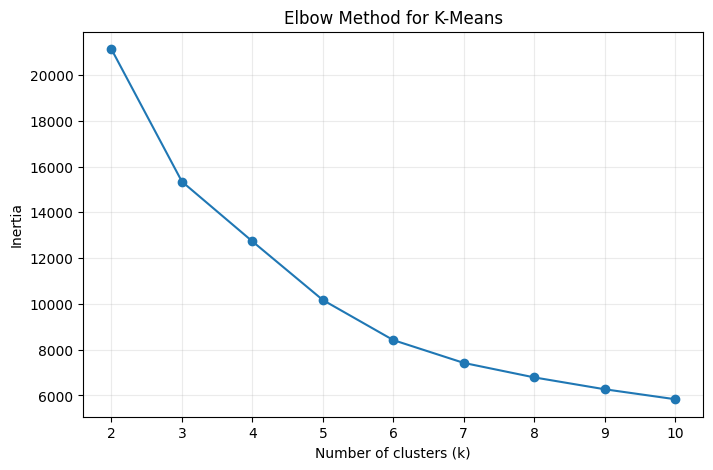

Selected K = 4


In [7]:
# 7. Elbow Method
k_values = range(2, 11)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    km.fit(X_scaled_df)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid(alpha=0.25)
plt.show()

# Default candidate; adjust after visually inspecting the elbow if your instructor expects a specific k.
K = 4
print("Selected K =", K)

In [8]:
# 8. K-Means clustering
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
customer_model["Cluster"] = kmeans.fit_predict(X_scaled_df)

sil_kmeans = silhouette_score(X_scaled_df, customer_model["Cluster"])
print(f"K-Means Silhouette Score: {sil_kmeans:.4f}")

display(customer_model["Cluster"].value_counts().sort_index().to_frame("Customers"))

K-Means Silhouette Score: 0.3781


,Customers
Cluster,
0,2055
1,583
2,1596
3,104


## 9. Hierarchical clustering and dendrogram

For the dendrogram, a sample is used when the customer count is large so the plot remains readable. Ward linkage is applied to standardized customer features.

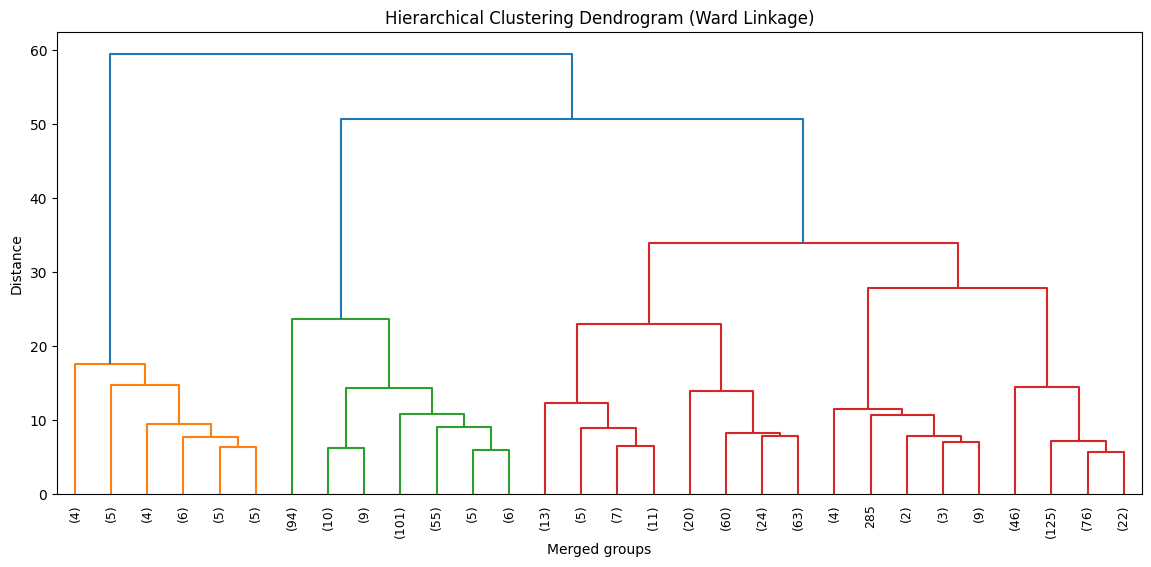

Dendrogram generated on sample size: 800


In [9]:
# 9. Hierarchical clustering / dendrogram
sample_n = min(800, len(X_scaled_df))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled_df), size=sample_n, replace=False)
X_hier = X_scaled_df.iloc[sample_idx]

Z = linkage(X_hier, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Merged groups")
plt.ylabel("Distance")
plt.show()

print("Dendrogram generated on sample size:", sample_n)

In [10]:
# Hierarchical cluster labels on the same sample for a quantitative comparison
from scipy.cluster.hierarchy import fcluster

hier_labels = fcluster(Z, t=K, criterion="maxclust")
hier_silhouette = silhouette_score(X_hier, hier_labels)

print(f"Hierarchical clustering Silhouette Score (sample): {hier_silhouette:.4f}")
print("K-Means and hierarchical scores are not perfectly apples-to-apples because the hierarchical score uses a readability sample.")

Hierarchical clustering Silhouette Score (sample): 0.3240
K-Means and hierarchical scores are not perfectly apples-to-apples because the hierarchical score uses a readability sample.


## 10. PCA visualization

PCA projects the standardized customer feature space into two dimensions for visualization. The PCA coordinates are not used to redefine the clusters.

Explained variance ratio: [0.50543215 0.19587216]
Total explained variance: 0.7013043098641756


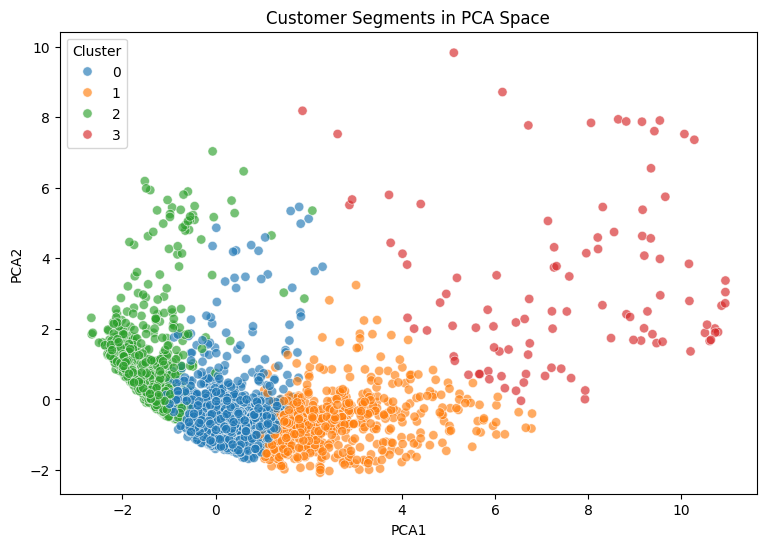

In [11]:
# 10. PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_df)

customer_model["PCA1"] = X_pca[:, 0]
customer_model["PCA2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print("Explained variance ratio:", explained)
print("Total explained variance:", explained.sum())

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=customer_model,
    x="PCA1", y="PCA2",
    hue="Cluster", palette="tab10", alpha=0.65, s=45
)
plt.title("Customer Segments in PCA Space")
plt.legend(title="Cluster")
plt.show()

## 11. Customer cluster profiling

Profiles are calculated from the original customer-level features. Because cluster numbers are arbitrary labels, interpretations should be based on the actual feature values rather than the numeric cluster ID.

In [12]:
# 11. Cluster profiles
profile = customer_model.groupby("Cluster")[features].agg(["mean", "median"])
display(profile.round(2))

# Compact profile with cluster size
profile_mean = customer_model.groupby("Cluster")[features].mean().round(2)
profile_mean.insert(0, "Customers", customer_model.groupby("Cluster").size())
display(profile_mean)

Recency        Frequency         Monetary           TotalQuantity  \
           mean median      mean median      mean    median          mean   
Cluster                                                                     
0         63.91   39.0      3.60    3.0   1113.65    873.74        653.25   
1         23.74   14.0     10.49    9.0   4121.11   3672.86       2415.01   
2        159.35  137.0      1.10    1.0    380.67    271.02        228.93   
3         18.43    5.0     31.30   22.5  34737.52  17189.94      19731.27   

                AvgTransactionValue        ProductDiversity         \
         median                mean median             mean median   
Cluster                                                              
0         498.0               27.78  17.91            51.95   44.0   
1        2114.0               19.85  17.27           176.61  158.0   
2         146.0               38.87  17.22            21.96   16.0   
3        9500.0             1594.30  83.17           226.03  117.0   

        PurchaseFrequency         
                     mean median  
Cluster                           
0                    0.03   0.02  
1                    0.05   0.03  
2                    1.03   1.00  
3                    0.16   0.07

,Customers,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,ProductDiversity,PurchaseFrequency
Cluster,,,,,,,,
0,2055,63.91,3.60,1113.65,653.25,27.78,51.95,0.03
1,583,23.74,10.49,4121.11,2415.01,19.85,176.61,0.05
2,1596,159.35,1.10,380.67,228.93,38.87,21.96,1.03
3,104,18.43,31.30,34737.52,19731.27,1594.30,226.03,0.16


In [13]:
# 12. Relative profile scores for easier interpretation
cluster_z = (profile_mean[features] - profile_mean[features].mean()) / profile_mean[features].std(ddof=0)
display(cluster_z.round(2))

print("Interpretation guide:")
print("- Lower Recency generally means more recent activity.")
print("- Higher Frequency, Monetary, TotalQuantity and ProductDiversity indicate stronger engagement/value.")
print("- Cluster labels themselves have no intrinsic business meaning.")

,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,ProductDiversity,PurchaseFrequency
Cluster,,,,,,,
0,-0.04,-0.68,-0.63,-0.63,-0.58,-0.79,-0.69
1,-0.75,-0.10,-0.42,-0.41,-0.59,0.68,-0.65
2,1.65,-0.89,-0.68,-0.68,-0.56,-1.15,1.72
3,-0.85,1.66,1.72,1.72,1.73,1.26,-0.38


Interpretation guide:
- Lower Recency generally means more recent activity.
- Higher Frequency, Monetary, TotalQuantity and ProductDiversity indicate stronger engagement/value.
- Cluster labels themselves have no intrinsic business meaning.


## 13. Define the high-value segment

The problem statement asks for an appropriate high-value segment based on the generated clusters. To make the rule reproducible rather than manually selecting a cluster ID, we create a composite value score from standardized Monetary, Frequency and Recency (with Recency direction reversed).

The highest-scoring cluster is then treated as the high-value segment for the supervised learning task.

In [14]:
# 13. High-value segment definition
value_base = customer_model[["Monetary", "Frequency", "Recency"]].copy()
value_scaled = StandardScaler().fit_transform(value_base)

value_df = pd.DataFrame(value_scaled, columns=value_base.columns, index=customer_model.index)
value_df["ValueScore"] = (
    value_df["Monetary"] + value_df["Frequency"] - value_df["Recency"]
) / 3

cluster_value = (
    customer_model.assign(ValueScore=value_df["ValueScore"])
    .groupby("Cluster")["ValueScore"]
    .mean()
    .sort_values(ascending=False)
)

high_value_cluster = int(cluster_value.index[0])
customer_model["HighValue"] = (customer_model["Cluster"] == high_value_cluster).astype(int)

print("Cluster mean ValueScore:")
display(cluster_value.to_frame())
print("High-value cluster:", high_value_cluster)
print("High-value customers:", customer_model["HighValue"].sum())

Cluster mean ValueScore:


,ValueScore
Cluster,
3,2.629485
1,0.575185
0,0.031472
2,-0.421976


High-value cluster: 3
High-value customers: 104


## 14. Supervised learning: Random Forest and SVM

The target is whether a customer belongs to the high-value cluster. Cluster ID and PCA coordinates are excluded from the predictor set to reduce direct leakage from the clustering assignment.

A stratified train/test split is used. The SVM uses an RBF kernel and class weighting to be more robust when the high-value class is smaller.

In [15]:
# 14. Prepare classification data
target = customer_model["HighValue"]

# Do not use Cluster/PCA/ValueScore-derived columns as predictors.
predictor_features = features
X_cls = X_raw[predictor_features].copy()
y_cls = target.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cls
)

clf_scaler = StandardScaler()
X_train_scaled = clf_scaler.fit_transform(X_train)
X_test_scaled = clf_scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)
svm = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
svm.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

print("Models trained.")

Models trained.


In [16]:
# 15. Evaluation metrics
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob),
    evaluate_model("SVM", y_test, svm_pred, svm_prob)
])

display(results.round(4))

print("Random Forest classification report")
print(classification_report(y_test, rf_pred, zero_division=0))

print("SVM classification report")
print(classification_report(y_test, svm_pred, zero_division=0))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9935,1.0000,0.7308,0.8444,0.9997
1,SVM,0.9972,0.8966,1.0000,0.9455,0.9999


Random Forest classification report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1059
           1       1.00      0.73      0.84        26

    accuracy                           0.99      1085
   macro avg       1.00      0.87      0.92      1085
weighted avg       0.99      0.99      0.99      1085

SVM classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1059
           1       0.90      1.00      0.95        26

    accuracy                           1.00      1085
   macro avg       0.95      1.00      0.97      1085
weighted avg       1.00      1.00      1.00      1085



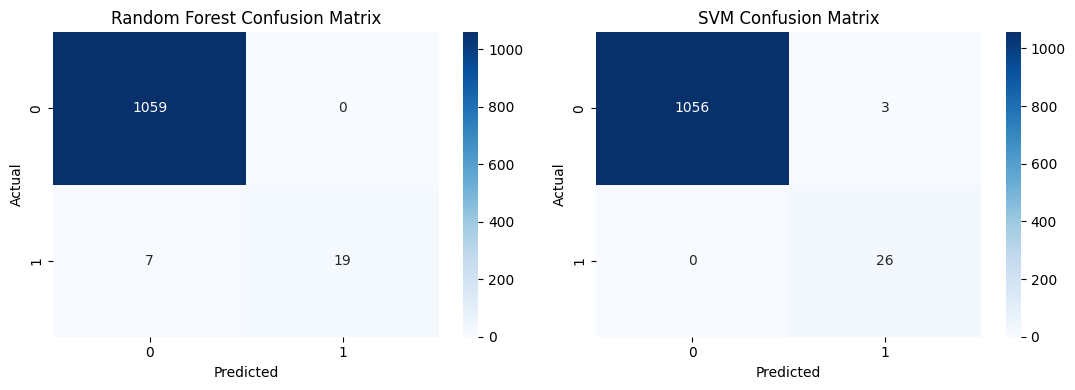

In [17]:
# 16. Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, pred in [
    (axes[0], "Random Forest", rf_pred),
    (axes[1], "SVM", svm_pred)
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 15. Feature importance analysis

Random Forest provides impurity-based feature importance. These values indicate which input features contributed most to the fitted forest; they should be interpreted as model-specific importance, not causal effects.

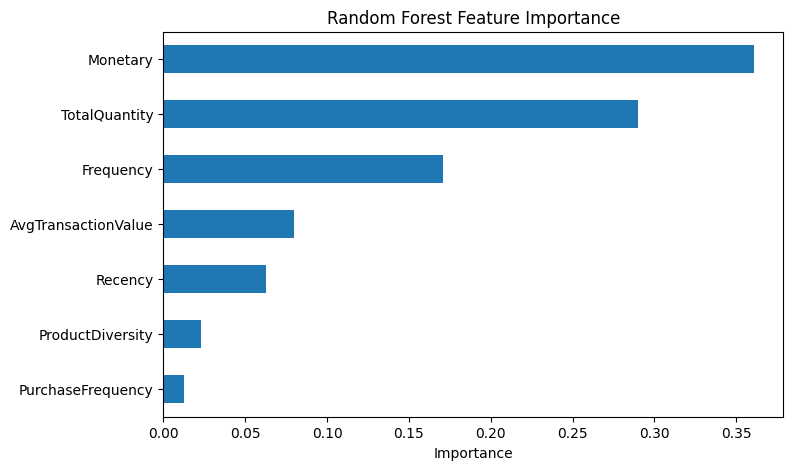

,Importance
Monetary,0.3607
TotalQuantity,0.2900
Frequency,0.1708
AvgTransactionValue,0.0799
Recency,0.0630
ProductDiversity,0.0230
PurchaseFrequency,0.0125


In [18]:
# 17. Random Forest feature importance
importance = pd.Series(rf.feature_importances_, index=predictor_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

display(importance.to_frame("Importance").round(4))

## 16. Interactive 3D visualization using Plotly

The assignment explicitly requires an interactive 3D visualization of customer clusters. The three axes below are the first three PCA components.

In [19]:
# 18. Interactive 3D cluster visualization
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_scaled_df)

plot_df = customer_model.copy()
plot_df["PCA1_3D"] = X_pca3[:, 0]
plot_df["PCA2_3D"] = X_pca3[:, 1]
plot_df["PCA3_3D"] = X_pca3[:, 2]
plot_df["ClusterLabel"] = plot_df["Cluster"].astype(str)

fig = px.scatter_3d(
    plot_df,
    x="PCA1_3D", y="PCA2_3D", z="PCA3_3D",
    color="ClusterLabel",
    hover_data=["CustomerID", "Recency", "Frequency", "Monetary", "HighValue"],
    title="Interactive 3D Customer Segments"
)
fig.update_traces(marker=dict(size=4))
fig.show()

## 17. Segment-wise marketing recommendations

The recommendations below are generated from measurable cluster characteristics. Replace the text with your own interpretation after reviewing the actual profile table if your instructor expects manually written business recommendations.

In [20]:
# 19. Generate profile-based recommendations
def segment_recommendation(row):
    # Relative to the overall customer mean.
    overall = profile_mean[features].mean()
    recency_low = row["Recency"] < overall["Recency"]
    freq_high = row["Frequency"] > overall["Frequency"]
    monetary_high = row["Monetary"] > overall["Monetary"]
    diversity_high = row["ProductDiversity"] > overall["ProductDiversity"]

    if row.name == high_value_cluster:
        action = "VIP retention, loyalty benefits, personalized offers and early access."
    elif recency_low and freq_high:
        action = "Cross-selling, bundles and loyalty/repeat-purchase incentives."
    elif not recency_low and (freq_high or monetary_high):
        action = "Reactivation campaigns, reminders and personalized win-back offers."
    elif diversity_high:
        action = "Product discovery, recommendations and category-based promotions."
    else:
        action = "Low-cost engagement campaigns and targeted introductory offers."

    return action

recommendations = profile_mean.apply(segment_recommendation, axis=1).to_frame("MarketingRecommendation")
recommendations.insert(0, "Customers", profile_mean["Customers"])
display(recommendations)

,Customers,MarketingRecommendation
Cluster,,
0,2055,Low-cost engagement campaigns and targeted int...
1,583,"Product discovery, recommendations and categor..."
2,1596,Low-cost engagement campaigns and targeted int...
3,104,"VIP retention, loyalty benefits, personalized ..."


## 18. Final interpretation

### What to report

After running the notebook, report:
- number of cleaned transactions and unique customers;
- selected K and the Elbow Method observation;
- K-Means Silhouette Score;
- hierarchical clustering Silhouette Score on the displayed sample;
- PCA explained variance;
- cluster profiles and their purchasing characteristics;
- the rule used to define the high-value segment;
- Random Forest and SVM Accuracy, Precision, Recall, F1 and ROC-AUC;
- confusion matrices;
- Random Forest feature importance;
- interactive 3D cluster visualization;
- segment-wise marketing recommendations.

### Conclusion template

The analysis transformed transaction-level online retail data into customer-level behavioral features and used unsupervised learning to identify customer segments. K-Means segmentation was validated with the Elbow Method and Silhouette Score, while hierarchical clustering provided a complementary view of the customer structure. PCA enabled two-dimensional visualization of the resulting segments.

The generated high-value segment was then used as the target for supervised prediction using Random Forest and SVM. Model performance should be compared using the reported classification metrics and confusion matrices. Finally, customer profiles can be translated into targeted marketing actions such as retention, cross-selling, reactivation and personalized engagement.

**Important:** Replace this template with the actual numerical results produced by your run before final submission.

## 19. Reproducibility checklist

- [x] UCI dataset download is automated.
- [x] Missing Customer IDs and invalid transactions are handled.
- [x] Cancellations are removed.
- [x] Customer-level RFM/purchasing features are created.
- [x] Outlier capping and scaling are included.
- [x] Elbow Method is included.
- [x] K-Means is included.
- [x] Hierarchical clustering and dendrogram are included.
- [x] Silhouette Score is included.
- [x] PCA 2D visualization is included.
- [x] Customer profiling is included.
- [x] High-value segment is defined reproducibly.
- [x] Random Forest and SVM are included.
- [x] Accuracy, Precision, Recall, F1 and ROC-AUC are included.
- [x] Confusion matrices are included.
- [x] Feature importance is included.
- [x] Plotly interactive 3D visualization is included.
- [x] Segment-wise recommendations are included.
